# load code (and packages, for now)

## loading packages

In [1]:
using LinearAlgebra

using NLsolve
using Sobol

using Contour
using StaticArrays
using GeometryBasics
using FastGaussQuadrature

In [2]:
using GLMakie

## including code files

In [3]:
pathtosrc="../src/1D/";

In [4]:
include(pathtosrc*"integration-path-flow.jl")
include(pathtosrc*"critical-points.jl")
include(pathtosrc*"line-intersection.jl")
include(pathtosrc*"saddle-point-method.jl")

# defining cuspoid functions

## first test: defining them explicitly, for k = 1:4

In [5]:
phi1(x::Vector) = t -> x[1] * t + t^3;
phi2(x::Vector) = t -> x[1]*t + x[2]*t^2 + t^4;
phi3(x::Vector) = t -> x[1]*t + x[2]*t^2 + x[3]*t^3 + t^5;
phi4(x::Vector) = t -> x[1]*t + x[2]*t^2 + x[3]*t^3 + x[4]*t^4 + t^6;

In [6]:
phi1drv(x::Vector) = t -> x[1]+ 3*t^2;
phi2drv(x::Vector) = t -> x[1]+ 2*x[2]*t + 4*t^3;
phi3drv(x::Vector) = t -> x[1]+ 2*x[2]*t + 3*x[3]*t^2 + 5*t^4;
phi4drv(x::Vector) = t -> x[1]+ 2*x[2]*t + 3*x[3]*t^2 + 4*x[4]*t^3 + 6*t^5;

In [7]:
let
    parameters = [2., 3., 4.] 
    tmin = complex(0.)
    tmax = complex(5., 5.)
    
    find_saddles_sobol(phi3drv(parameters), tmin, tmax)
end

3-element Vector{ComplexF64}:
 -0.26 + 0.31im
 -0.26 - 0.31im
  0.26 + 1.56im

# get thimble and integrate

## first tests

integrate_thimble(cuspoid, points, simplices) = 0.08410642221075115 - 0.21413924996379533im
  2.265891 seconds (2.12 M allocations: 102.811 MiB, 99.72% compilation time)


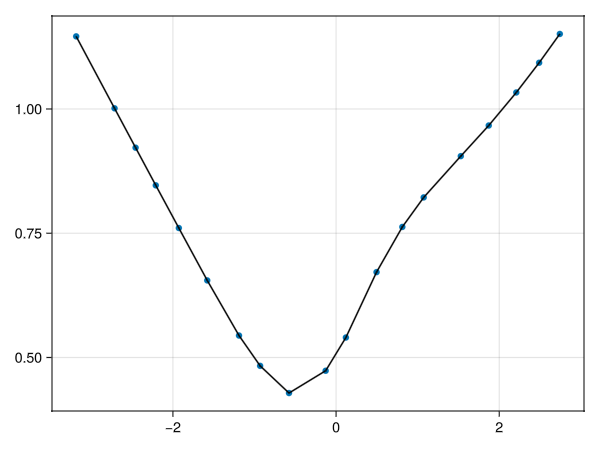

In [8]:
let
    #####
    Nsteps = 50
    flowfactor = 0.1
    δ = 0.5
    tmin = -10.
    tmax = 10.
    Δinit = 0.5
    
    xvec = [5., 5., 5.]
    ### define your phase functions, as functions of 't' only
    cuspoid(t) = phi3(xvec)(t)
    cuspoid_drv(t) = phi3drv(xvec)(t)
    #########

#     @show cuspoid(tmin)
    @time begin
    points, simplices = get_thimble(cuspoid, cuspoid_drv, real(tmin), real(tmax),
        Nflow = Nsteps,
        flowstepfactor = flowfactor,
        h_threshold=-600.,
        Δinit=Δinit,
        subdividethreshold=δ)
    
#     display(simplices)
    @show integrate_thimble(cuspoid, points, simplices)
    end
    
    fig = Figure()
    ax = Axis(fig[1,1])
    
        scatter!([reim(p.coord) for p in points if p.active])
        for seg in simplices
            if seg.active
                lines!(ax,[reim.(p.coord) for p in points[seg.coord]], color=:black)
            end
        end
    
    fig
end

## density plot for the Pearcey integral
like here: https://dlmf.nist.gov/36.3

In [55]:
Nxy = 101
xvals = range(-10., stop = 10., length=Nxy)
yvals = range(-9., stop = 2., length=Nxy);

-9.0:0.11:2.0

In [59]:
pi_data = zeros(ComplexF64,Nxy,Nxy);

In [60]:
let
    #####
    Nsteps = 50
    flowfactor = 0.1
    δ = 0.5
    tmin = -10.
    tmax = 10.
    Δinit = 0.5
    #####
    
    for (iy, y) in enumerate(yvals), (ix, x) in enumerate(xvals)
        xvec = [x,y]
        cuspoid(t) = phi2(xvec)(t)
        cuspoid_drv(t) = phi2drv(xvec)(t)
        
        points, simplices = get_thimble(cuspoid, cuspoid_drv, real(tmin), real(tmax),
            Nflow = Nsteps,
            flowstepfactor = flowfactor,
            h_threshold=-600.,
            Δinit=Δinit,
            subdividethreshold=δ)
        
         pi_data[ix,iy] = integrate_thimble(cuspoid, points, simplices)
    end

end

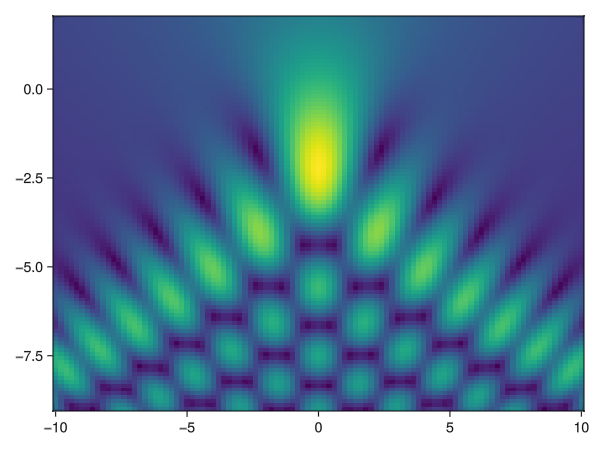

In [58]:
let
    fig = Figure()
    ax = Axis(fig[1,1])
    
    heatmap!(ax, xvals, yvals, abs.(pi_data))
    fig
end

## contour plot

ts = -0.46 + 0.0im
ts = 0.23 - 1.63im
ts = 0.23 + 1.63im


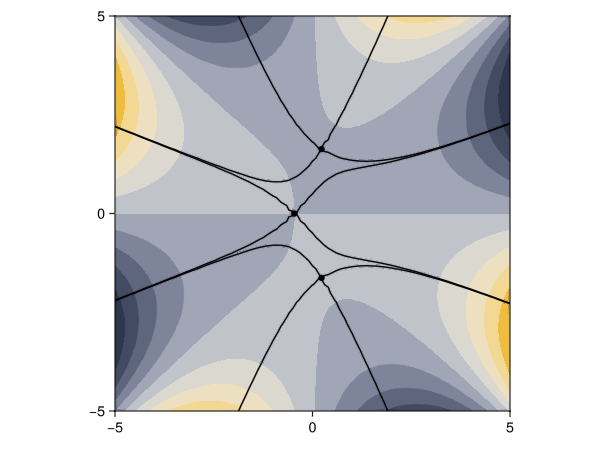

In [9]:
let
    xvec = [5., 5.]
    ### define your phase functions, as functions of 't' only
    cuspoid(t) = phi2(xvec)(t)
    cuspoid_drv(t) = phi2drv(xvec)(t)
    
    tmin = -5.
    tmax = 5.
    timax = 5.
    
    saddles = find_saddles_sobol(cuspoid_drv, tmin-timax*im, tmax+timax*im)
    
        
    timags = range(-timax, stop = timax, length = 51)
    treals = range(real(tmin), stop = real(tmax), length = 51)
    Δi = timags[2]-timags[1]
    Δr = treals[2]-treals[1]
    crossthresh = sqrt((Δi)^2 + (Δr)^2)
#     @show crossthresh
    
    Φvals = [cuspoid(tr + im*ti) for tr in treals, ti in timags]
       
    f = Figure() #size=(900, 400)) #, fontsize=20)
    ax = Axis(f[1, 1], aspect=DataAspect())
    
    cmap = :grayyellow
    contourf!(ax, treals, timags, -imag.(Φvals)
        , colormap=cmap
        , extendlow = :white, extendhigh = :white
    )
    
#     contour!(ax, treals, timags, -imag.(Svals)
#         , levels=31, color=:grey, linewidth=0.85)   
    
#     contour!(ax, treals, timags, real.(Svals)
#         , levels=31, color=:grey, linewidth=0.85)
    
    real_axis = Curve2([(real(tmin)-5, 0.), (real(tmax)+5, 0.)])    

    for ts in saddles
        relevant = false
        @show ts
        Φ_saddle = cuspoid(ts)
        contour_saddle_real = Contour.contour(collect(treals), collect(timags), real.(Φvals), real.(Φ_saddle))

        for curve in contour_saddle_real.lines
            saddle_ip = crosses_point(curve, Point(reim(ts)...), crossthresh)
            if !(saddle_ip==false)              
                lines!(ax, Contour.coordinates(curve)..., color = :black)
            end 
        
        end
    end
    
    scatter!(ax, reim(saddles)..., color = :black)
    f
end

## plotting the thimble on top of the contour plot

integrate_thimble(cuspoid, points, simplices) = 1.20758645114184 + 0.6015340860572223im
ts = -0.19 + 0.78im
ts = -0.19 - 0.78im
ts = 0.39 + 0.0im


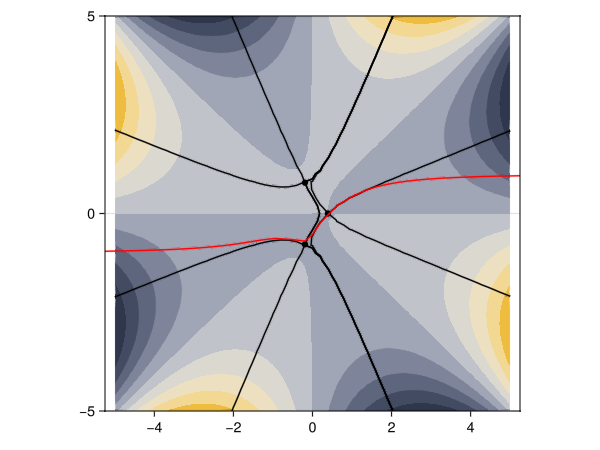

In [14]:
let
    xvec = [-1., 1.]
    ### define your phase functions, as functions of 't' only
    cuspoid(t) = phi2(xvec)(t)
    cuspoid_drv(t) = phi2drv(xvec)(t)
    
    tmin = -5.
    tmax = 5.
    timax = 5.
    
    ### getting saddle points
    saddles = find_saddles_sobol(cuspoid_drv, tmin-timax*im, tmax+timax*im)
    
    ### make time grid and calculate values   
    timags = range(-timax, stop = timax, length = 51)
    treals = range(real(tmin), stop = real(tmax), length = 51)
    Δi = timags[2]-timags[1]
    Δr = treals[2]-treals[1]
    crossthresh = sqrt((Δi)^2 + (Δr)^2)
    Φvals = [cuspoid(tr + im*ti) for tr in treals, ti in timags]
    
    ### find thimble
    Nsteps = 50
    flowfactor = 0.1
    δ = 0.5
    tmin = -10.
    tmax = 10.
    Δinit = 0.5
    #####
    points, simplices = get_thimble(cuspoid, cuspoid_drv, real(tmin), real(tmax),
        Nflow = 10,
        flowstepfactor = flowfactor,
        h_threshold=-600.,
        Δinit=Δinit,
        subdividethreshold=δ)    
    @show integrate_thimble(cuspoid, points, simplices)

    
    ### plotting
    f = Figure() #size=(900, 400)) #, fontsize=20)
    ax = Axis(f[1, 1], aspect=DataAspect())
    
    cmap = :grayyellow
    contourf!(ax, treals, timags, -imag.(Φvals)
        , colormap=cmap
        , extendlow = :white, extendhigh = :white
    )
    
    ### contour level lines
    #     contour!(ax, treals, timags, -imag.(Svals)
    #         , levels=31, color=:grey, linewidth=0.85)   

    #     contour!(ax, treals, timags, real.(Svals)
    #         , levels=31, color=:grey, linewidth=0.85)

    #     real_axis = Curve2([(real(tmin)-5, 0.), (real(tmax)+5, 0.)])    

    ### plot contour lines for saddle points
    for ts in saddles
        relevant = false
        @show ts
        Φ_saddle = cuspoid(ts)
        contour_saddle_real = Contour.contour(collect(treals), collect(timags), real.(Φvals), real.(Φ_saddle))

        for curve in contour_saddle_real.lines
            saddle_ip = crosses_point(curve, Point(reim(ts)...), crossthresh)
            if !(saddle_ip==false)              
                lines!(ax, Contour.coordinates(curve)..., color = :black)
            end 
        
        end
    end
    
    ### plot saddle points
    scatter!(ax, reim(saddles)..., color = :black)
    
    ### plot the thimble
#     scatter!([reim(p.coord) for p in points if p.active])
    for seg in simplices
        if seg.active
            lines!(ax,[reim.(p.coord) for p in points[seg.coord]], color=:red)
        end
    end
    
    f
end

integrate_thimble(cuspoid, points, simplices) = 0.647612871390812 - 0.28809571869525413im
ts = -0.23 + 1.63im
relevant = false

ts = -0.23 - 1.63im
relevant = false

ts = 0.46 + 0.0im
relevant = true



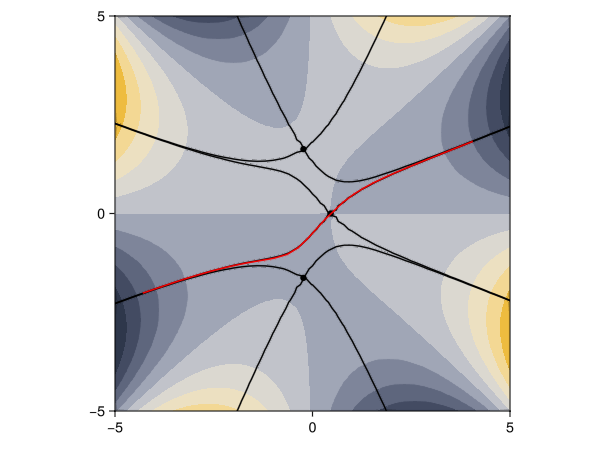

In [11]:
let
    xvec = [-5., 5.]
    ### define your phase functions, as functions of 't' only
    cuspoid(t) = phi2(xvec)(t)
    cuspoid_drv(t) = phi2drv(xvec)(t)
    
    tmin = -5.
    tmax = 5.
    timax = 5.
    
    ### getting saddle points
    saddles = find_saddles_sobol(cuspoid_drv, tmin-timax*im, tmax+timax*im)
    
    ### make time grid and calculate values   
    timags = range(-timax, stop = timax, length = 51)
    treals = range(real(tmin), stop = real(tmax), length = 51)
    Δi = timags[2]-timags[1]
    Δr = treals[2]-treals[1]
    crossthresh = sqrt((Δi)^2 + (Δr)^2)
    Φvals = [cuspoid(tr + im*ti) for tr in treals, ti in timags]
    
    ### find thimble
    Nsteps = 50
    flowfactor = 0.1
    δ = 0.5
    tmin = -10.
    tmax = 10.
    Δinit = 0.5
    #####
    points, simplices = get_thimble(cuspoid, cuspoid_drv, real(tmin), real(tmax),
        Nflow = Nsteps,
        flowstepfactor = flowfactor,
        h_threshold=-600.,
        Δinit=Δinit,
        subdividethreshold=δ)    
    @show integrate_thimble(cuspoid, points, simplices)

    
    ### plotting
    f = Figure() #size=(900, 400)) #, fontsize=20)
    ax = Axis(f[1, 1], aspect=DataAspect())
    
    cmap = :grayyellow
    contourf!(ax, treals, timags, -imag.(Φvals)
        , colormap=cmap
        , extendlow = :white, extendhigh = :white
    )
    
    ### contour level lines
    #     contour!(ax, treals, timags, -imag.(Svals)
    #         , levels=31, color=:grey, linewidth=0.85)   

    #     contour!(ax, treals, timags, real.(Svals)
    #         , levels=31, color=:grey, linewidth=0.85)

    #     real_axis = Curve2([(real(tmin)-5, 0.), (real(tmax)+5, 0.)])    

    ### plot contour lines for saddle points
    for ts in saddles
        relevant = false
        @show ts
        relevant = is_contributing(ts, cuspoid, complex(minimum(treals), minimum(timags)), complex(maximum(treals), maximum(timags)))
        @show relevant
        
        Φ_saddle = cuspoid(ts)
        contour_saddle_real = Contour.contour(collect(treals), collect(timags), real.(Φvals), real.(Φ_saddle))
        println()
        
        for curve in contour_saddle_real.lines
            saddle_ip = crosses_point(curve, Point(reim(ts)...), crossthresh)
            if !(saddle_ip==false)              
                lines!(ax, Contour.coordinates(curve)..., color = :black)
            end 
        
        end
    end
    
    ### plot saddle points
    scatter!(ax, reim(saddles)..., color = :black)
    
    ### plot the thimble
#     scatter!([reim(p.coord) for p in points if p.active])
    for seg in simplices
        if seg.active
            lines!(ax,[reim.(p.coord) for p in points[seg.coord]], color=:red)
        end
    end
    
    f
end

## integrate directly

In [102]:
let
    #####
    Nsteps = 50
    flowfactor = 0.1
    δ = 0.5
    tmin = -10.
    tmax = 10.
    Δinit = 0.5
    
    xvec = [0., 0., 0.]
    ### define your phase functions, as functions of 't' only
    cuspoid(t) = phi3(xvec)(t)
    cuspoid_drv(t) = phi3drv(xvec)(t)
    #########

    int, _ = integrate_thimble(cuspoid, cuspoid_drv, tmin, tmax, print_message=false,
        Nmax = Nsteps,
        flowstepfactor = flowfactor,
        h_threshold=-600.,
        Δinit=Δinit,
        subdividethreshold=δ)
    
    @show int
end

int = 1.746460702072036 + 1.5452177587973475e-17im


1.746460702072036 + 1.5452177587973475e-17im

In [68]:
let
    xvec = [5., 5.]

    cuspoid(t) = phi2(xvec)(t)
    cuspoid_drv(t) = phi2drv(xvec)(t)
    cuspoid(5. +2im)
end

171.0 + 950.0im